In [13]:
%pip install rawpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\gmone\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import rawpy
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

def display_raw_image(file_path):
    with rawpy.imread(file_path) as raw:
        raw_data = raw.raw_image_visible.copy()
        camXYZmatr = np.asarray(raw.rgb_xyz_matrix)
        white_balance = np.asarray(raw.camera_whitebalance)
        
        # Capture levels
        black_level = raw.black_level_per_channel[0]
        white_level = raw.white_level
        
        white_balance /= white_balance[1]

    return raw_data, white_balance, camXYZmatr, black_level, white_level

# Update the call
new_arr, camera_white_bal, camXYZ_matrix, blk, wht = display_raw_image("IMG/IMG_0341.CR3")

new_arr = new_arr.astype("float64")
camera_white_bal, camXYZ_matrix = camera_white_bal.astype("float64"), camXYZ_matrix.astype("float64")



Linearization

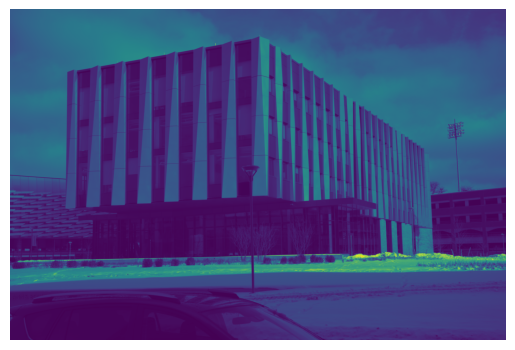

In [15]:
# Linearize using camera levels
new_arr = (new_arr - blk) / (wht - blk)
new_arr = np.clip(new_arr, 0, 1)

plt.imshow(new_arr)
plt.axis("off")
plt.show()

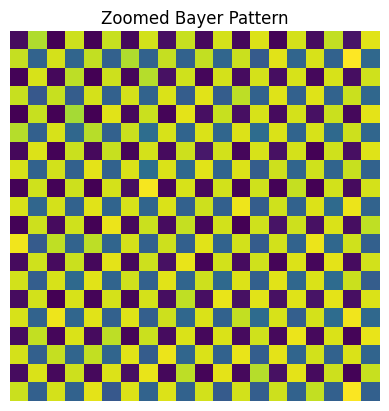

In [16]:
row1, row2 = 20, 40
column1, column2 = 20, 40

crop = new_arr[row1:row2, column1:column2]

plt.imshow(crop)
plt.axis("off")
plt.title("Zoomed Bayer Pattern")
plt.show()

White Balancing

In [17]:
def gray_world(image):
    avgR = np.mean(image[::2, ::2])
    avgG1 = np.mean(image[::2, 1::2])
    avgG2 = np.mean(image[1::2, ::2])
    avgB = np.mean(image[1::2, 1::2])
    avgG = (avgG1 + avgG2) / 2

    Kr = avgG / avgR
    Kg = 1
    Kb = avgG / avgB

    corrected_image = image.copy()
    corrected_image[::2, ::2] *= Kr
    corrected_image[::2, 1::2] *= Kg
    corrected_image[1::2, ::2] *= Kg
    corrected_image[1::2, 1::2] *= Kb

    return corrected_image


def white_world(image):
    maxR = np.max(image[::2, ::2])
    maxG1 = np.max(image[::2, 1::2])
    maxG2 = np.max(image[1::2, ::2])
    maxB = np.max(image[1::2, 1::2])
    maxG = (maxG1 + maxG2) / 2

    Kr = maxG / maxR
    Kg = 1
    Kb = maxG / maxB

    corrected_image = image.copy()
    corrected_image[::2, ::2] *= Kr
    corrected_image[::2, 1::2] *= Kg
    corrected_image[1::2, ::2] *= Kg
    corrected_image[1::2, 1::2] *= Kb

    return corrected_image

def camera_preset(image):
    red_m, green_m, blue_m, _ = camera_white_bal
    corrected_image = image.copy()
    corrected_image[::2, ::2] *= red_m
    corrected_image[::2, 1::2] *= green_m
    corrected_image[1::2, ::2] *= green_m
    corrected_image[1::2, 1::2] *= blue_m

    return corrected_image

white_world_image = white_world(new_arr.copy())

gray_world_image = gray_world(new_arr.copy())

camera_preset_image = camera_preset(new_arr.copy())

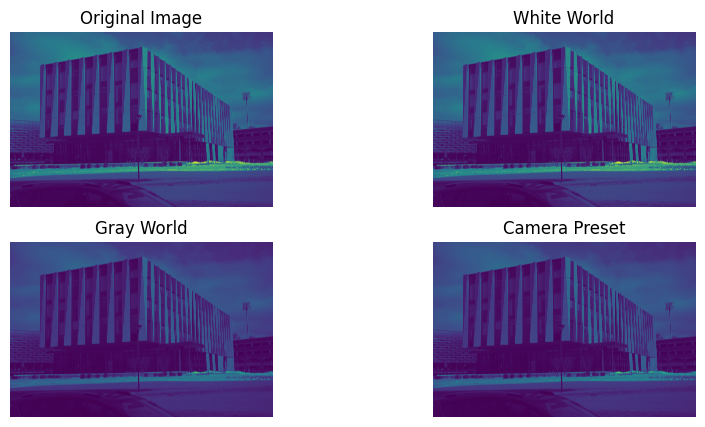

In [18]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5))

ax[0, 0].imshow(new_arr)
ax[0, 0].axis("off")
ax[0, 0].set_title("Original Image")

ax[0, 1].imshow(white_world_image)
ax[0, 1].axis("off")
ax[0, 1].set_title("White World")

ax[1, 0].imshow(gray_world_image)
ax[1, 0].axis("off")
ax[1, 0].set_title("Gray World")

ax[1, 1].imshow(camera_preset_image)
ax[1, 1].axis("off")
ax[1, 1].set_title("Camera Preset")

plt.show()

Demosaicing

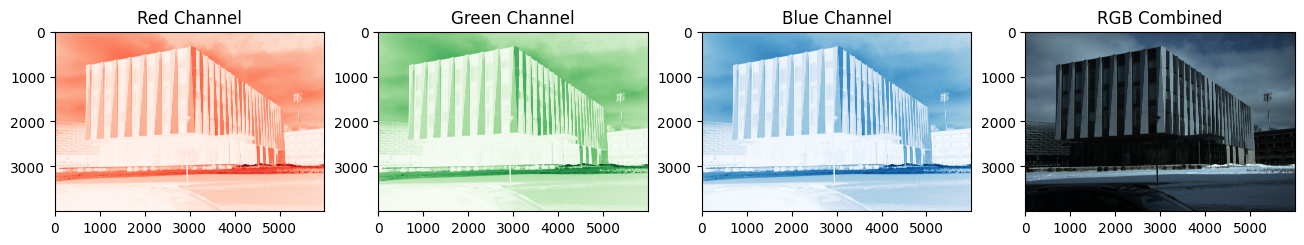

In [19]:
def bilinear_demosaic(image):
    H, W = image.shape

    r_rows, r_cols = np.arange(0, H, 2), np.arange(0, W, 2)
    R_values = image[::2, ::2]
    R_spline = RectBivariateSpline(r_rows, r_cols, R_values, kx=1, ky=1)
    R_full = R_spline(np.arange(H), np.arange(W))

    b_rows, b_cols = np.arange(1, H, 2), np.arange(1, W, 2)
    B_values = image[1::2, 1::2]
    B_spline = RectBivariateSpline(b_rows, b_cols, B_values, kx=1, ky=1)
    B_full = B_spline(np.arange(H), np.arange(W))

    g1_rows, g1_cols = np.arange(0, H, 2), np.arange(1, W, 2)
    G1_values = image[::2, 1::2]
    G1_spline = RectBivariateSpline(g1_rows, g1_cols, G1_values, kx=1, ky=1)
    G1_full = G1_spline(np.arange(H), np.arange(W))

    g2_rows, g2_cols = np.arange(1, H, 2), np.arange(0, W, 2)
    G2_values = image[1::2, ::2]
    G2_spline = RectBivariateSpline(g2_rows, g2_cols, G2_values, kx=1, ky=1)
    G2_full = G2_spline(np.arange(H), np.arange(W))

    G_full = (G1_full + G2_full) / 2

    RGBImage = np.stack([R_full, G_full, B_full], axis=-1)
    RGBImage = np.clip(RGBImage, 0, 1)

    return RGBImage


demosaiced_image = bilinear_demosaic(camera_preset_image)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(demosaiced_image[:, :, 0], cmap="Reds")
axes[0].set_title("Red Channel")
axes[1].imshow(demosaiced_image[:, :, 1], cmap="Greens")
axes[1].set_title("Green Channel")
axes[2].imshow(demosaiced_image[:, :, 2], cmap="Blues")
axes[2].set_title("Blue Channel")
axes[3].imshow(demosaiced_image)
axes[3].set_title("RGB Combined")
plt.show()

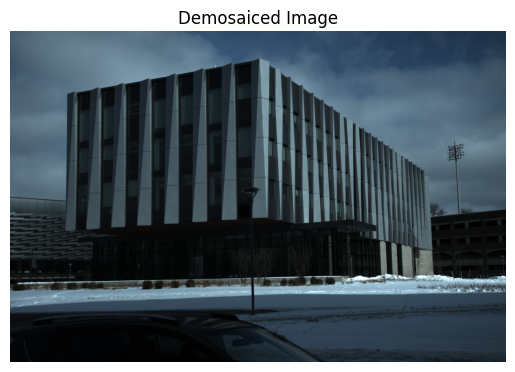

In [20]:
plt.imshow(demosaiced_image)
plt.axis("off")
plt.title("Demosaiced Image")
plt.show()

Color Space Correction

[0.20145412 0.25928722 0.29812902]
[0.1596395  0.24813172 0.32696446]


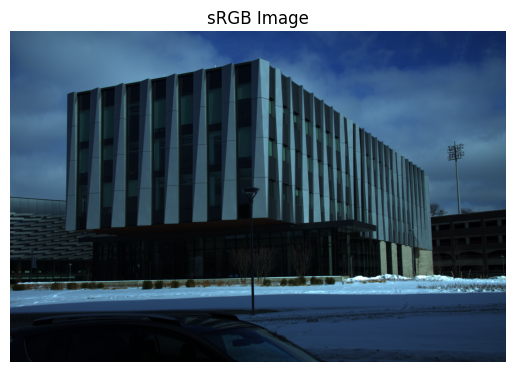

In [21]:
M_sRGB_to_XYZ = np.array([
    [0.4124564, 0.3575761, 0.1804375],
    [0.2126729, 0.7151522, 0.0721750],
    [0.0193339, 0.1191920, 0.9503041],
])

print(np.mean(demosaiced_image.reshape(-1, 3), axis=0))

M_cam_to_XYZ = camXYZ_matrix[:3, :3].copy()

M_sRGB_to_cam = M_cam_to_XYZ @ M_sRGB_to_XYZ
# normalize
row_sums = M_sRGB_to_cam.sum(axis=1, keepdims=True)
M_sRGB_to_cam_normalized = M_sRGB_to_cam / row_sums

M_cam_to_sRGB = np.linalg.inv(M_sRGB_to_cam_normalized)

# apply
sRGB_image = demosaiced_image @ M_cam_to_sRGB.T
sRGB_image = np.clip(sRGB_image, 0, 1)

print(np.mean(sRGB_image.reshape(-1, 3), axis=0))

plt.imshow(sRGB_image)
plt.axis("off")
plt.title("sRGB Image")
plt.show()

In [22]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\gmone\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Brightness

0.23501096226734458


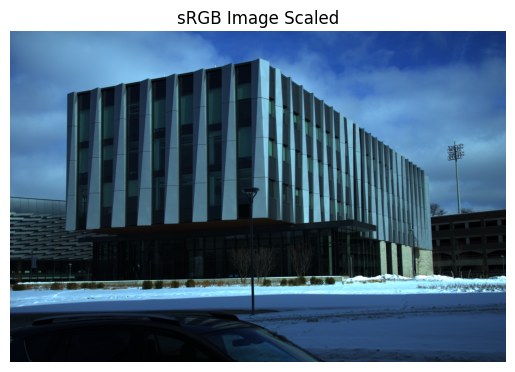

In [23]:
from skimage.color import rgb2gray
gray = rgb2gray(sRGB_image)
mean_gray = gray.mean()
print(mean_gray)
target_mean = 0.31
scale = target_mean / mean_gray
sRGB_image_scaled = np.clip(sRGB_image * scale, 0, 1)
plt.imshow(sRGB_image_scaled)
plt.axis("off")
plt.title("sRGB Image Scaled")
plt.show()

Gamma Encoding

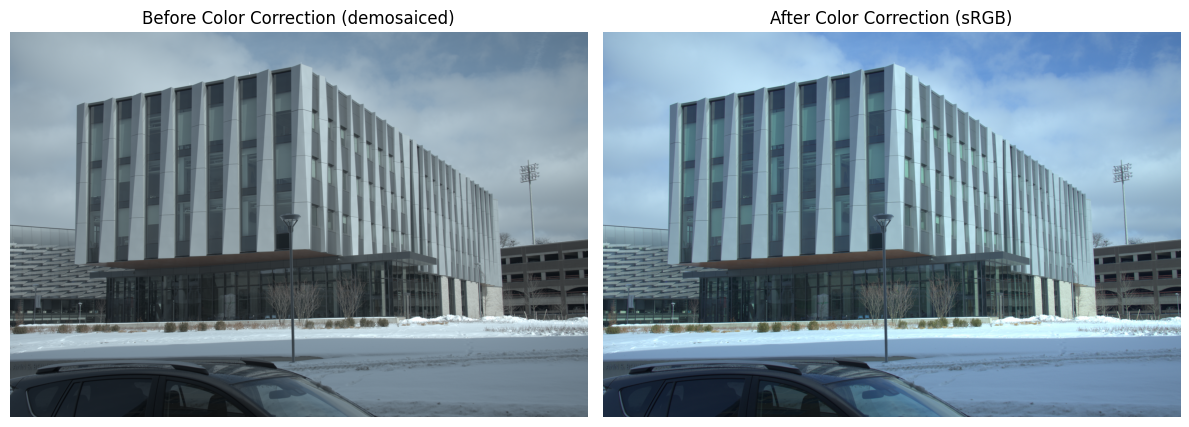

In [ ]:
def linear_to_sRGB_gamma(linear):
    """Convert linear sRGB to gamma-encoded sRGB for display"""
    gamma_encoded = np.where(
        linear <= 0.0031308,
        12.92 * linear,
        1.055 * np.power(linear, 1/2.4) - 0.055
    )
    return gamma_encoded

sRGB_display = linear_to_sRGB_gamma(sRGB_image_scaled)
sRGB_display = np.clip(sRGB_display, 0, 1)

# Show before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(linear_to_sRGB_gamma(demosaiced_image))
axes[0].set_title("Before Color Correction (demosaiced)")
axes[0].axis("off")

axes[1].imshow(sRGB_display)
axes[1].set_title("After Color Correction (sRGB)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Compression

In [36]:
import imageio
final_image_uint8 = (sRGB_display * 255).astype(np.uint8)

imageio.imwrite('developed_image.png', final_image_uint8)

imageio.imwrite('developed_image.jpg', final_image_uint8, quality=95)

import os
size_png = os.path.getsize('developed_image.png')
size_jpg = os.path.getsize('developed_image.jpg')
compression_ratio = size_png / size_jpg

print(f"PNG Size: {size_png} bytes")
print(f"JPEG Size (Q95): {size_jpg} bytes")
print(f"Compression Ratio: {compression_ratio:.2f}")

PNG Size: 25846226 bytes
JPEG Size (Q95): 3928240 bytes
Compression Ratio: 6.58


Manuel White Balancing

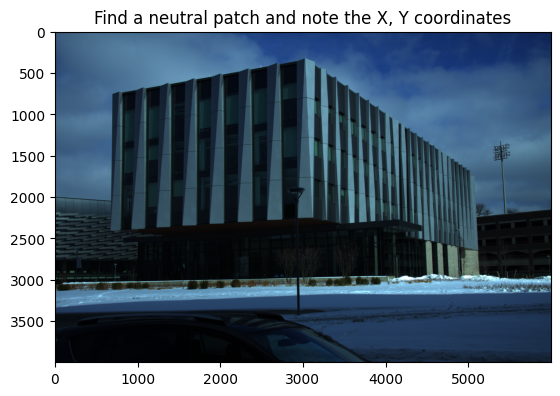

Manual White Balance Gains: R=1.305, G=1.000, B=0.942


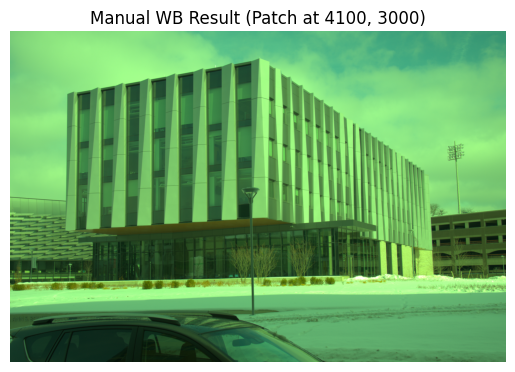

In [74]:
plt.imshow(np.clip(sRGB_image, 0, 1))
plt.title("Find a neutral patch and note the X, Y coordinates")
plt.axis('on') 
plt.show()

patch_x, patch_y = 4100, 3000
window_size = 10              


patch = sRGB_image[patch_y:patch_y+window_size, patch_x:patch_x+window_size, :]
avg_rgb = np.mean(patch, axis=(0, 1))

r_gain = avg_rgb[1] / avg_rgb[0]
g_gain = 1.0
b_gain = avg_rgb[1] / avg_rgb[2]

print(f"Manual White Balance Gains: R={r_gain:.3f}, G={g_gain:.3f}, B={b_gain:.3f}")

manual_mosaic = new_arr.copy()
manual_mosaic[0::2, 0::2] *= r_gain
manual_mosaic[1::2, 1::2] *= b_gain

manual_demosaiced = bilinear_demosaic(manual_mosaic)

manual_sRGB_linear = manual_demosaiced @ M_cam_to_sRGB.T

manual_sRGB_scaled = np.clip(manual_sRGB_linear * scale, 0, 1)

manual_final = linear_to_sRGB_gamma(manual_sRGB_scaled)

plt.imshow(manual_final)
plt.title(f"Manual WB Result (Patch at {patch_x}, {patch_y})")
plt.axis("off")
plt.show()

Comparions

C:\Users\gmone\AppData\Local\Temp\ipykernel_8592\764800659.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  camera_jpg = imageio.imread("IMG/IMG_0341.JPG")


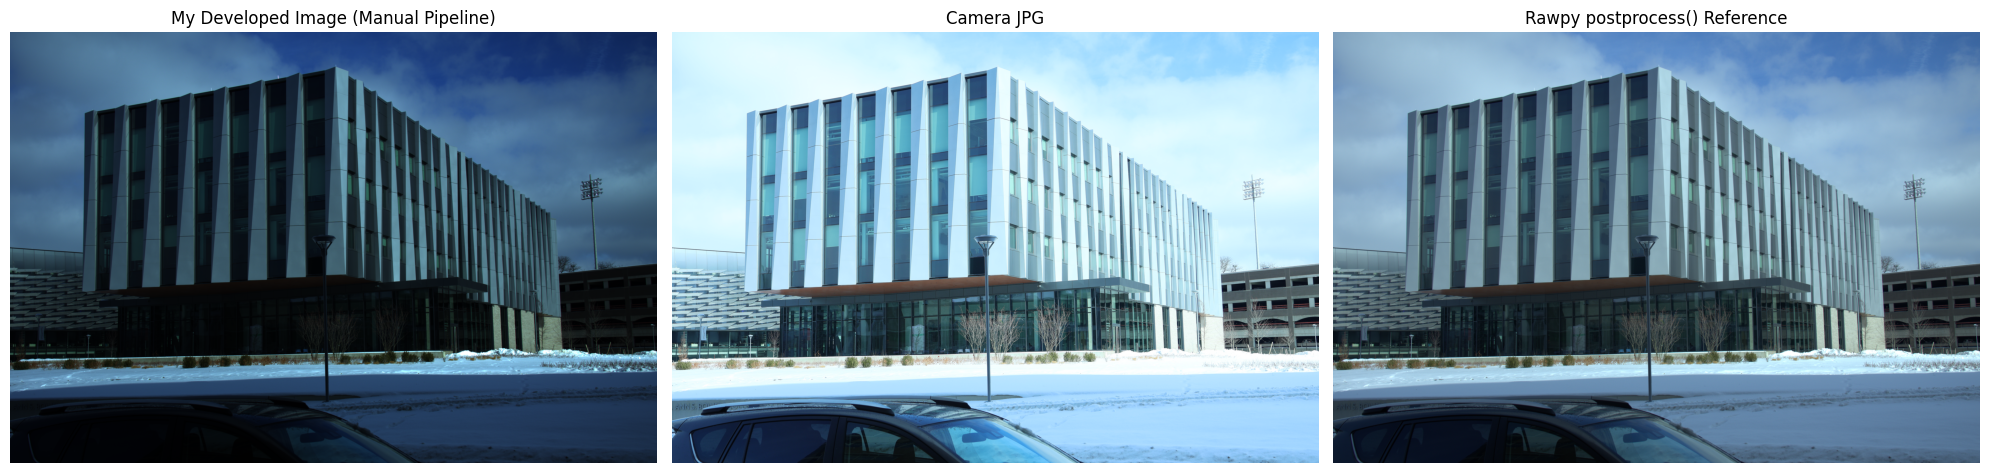

In [43]:
with rawpy.imread("IMG/IMG_0341.CR3") as raw:
    ref_rawpy = raw.postprocess(use_camera_wb=True, no_auto_bright=False, bright=1.0)

camera_jpg = imageio.imread("IMG/IMG_0341.JPG")

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(sRGB_image)
axes[0].set_title("My Developed Image (Manual Pipeline)")
axes[0].axis("off")

axes[1].imshow(camera_jpg)
axes[1].set_title("Camera JPG")
axes[1].axis("off")

axes[2].imshow(ref_rawpy)
axes[2].set_title("Rawpy postprocess() Reference")
axes[2].axis("off")

plt.tight_layout()
plt.show()